In [1]:
import matplotlib.pyplot as plt
import yfinance as yf
import pandas as pd
import numpy as np

# Ballarpur Industries Ltd. Analysis

In [5]:
def get_data(start_date, end_date):
    ticker = "BALLARPUR.NS"
    
    data = yf.download(
        ticker,
        start=start_date,
        end=end_date,
        interval="1d"   
    )

    # Handle multi-level columns if present
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)

    return data

In [7]:
data = get_data("2017-01-01", "2023-06-23")

[*********************100%***********************]  1 of 1 completed


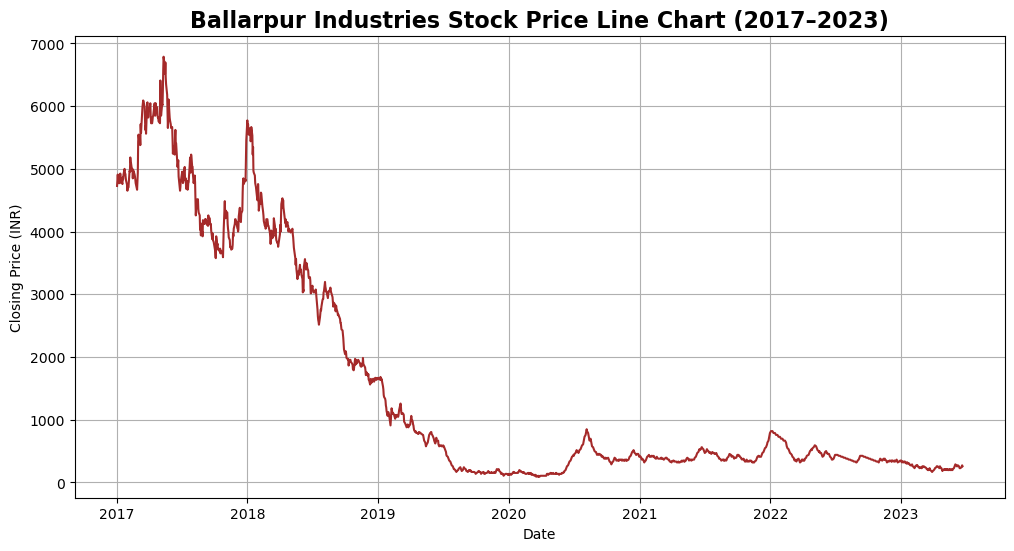

In [9]:
# Line chart 
plt.figure(figsize=(12,6))
plt.plot(data.index, data["Close"], color='brown')
plt.title("Ballarpur Industries Stock Price Line Chart (2017–2023)", fontsize=16, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Closing Price (INR)")
plt.grid()
plt.show()

In [11]:
# The stock shows a downward trend over time, indicating decline in value.
# Early periods show sharp rises and falls, indicating high volatility and unstable market behavior.
# A steep decline is observed around 2018–2019.
# After the crash, the stock stabilizes at very low levels with reduced price movement.
# From 2020 onwards, the trend remains mostly sideways with occasional small spikes, suggesting weak recovery and low trading activity.

### Trend Analysis Using Moving Averages

In [13]:
data['MA20'] = data['Close'].rolling(window=20).mean()
data['MA50'] = data['Close'].rolling(window=50).mean()
data

Price,Close,High,Low,Open,Volume,MA20,MA50
Date,,,,,,,
2017-01-02,4727.272949,4757.575684,4696.969727,4742.424316,922,NaN,NaN
2017-01-03,4818.181641,4893.939453,4681.818359,4757.575684,2723,NaN,NaN
2017-01-04,4909.090820,4984.848633,4803.030273,4818.181641,3124,NaN,NaN
2017-01-05,4803.030273,4939.394043,4772.727051,4909.090820,1434,NaN,NaN
2017-01-06,4772.727051,4878.788086,4742.424316,4803.030273,1483,NaN,NaN
...,...,...,...,...,...,...,...
2023-06-16,227.272720,242.424240,212.121216,227.272720,3264,240.151509,227.272724
2023-06-19,242.424240,242.424240,227.272720,242.424240,5359,242.424236,227.878784
2023-06-20,257.575745,257.575745,257.575745,257.575745,3888,244.696963,228.484845


In [15]:
data['Trend'] = 'Downtrend'
data.loc[data['MA20'] > data['MA50'], 'Trend'] = 'Uptrend'
data

Price,Close,High,Low,Open,Volume,MA20,MA50,Trend
Date,,,,,,,,
2017-01-02,4727.272949,4757.575684,4696.969727,4742.424316,922,NaN,NaN,Downtrend
2017-01-03,4818.181641,4893.939453,4681.818359,4757.575684,2723,NaN,NaN,Downtrend
2017-01-04,4909.090820,4984.848633,4803.030273,4818.181641,3124,NaN,NaN,Downtrend
2017-01-05,4803.030273,4939.394043,4772.727051,4909.090820,1434,NaN,NaN,Downtrend
2017-01-06,4772.727051,4878.788086,4742.424316,4803.030273,1483,NaN,NaN,Downtrend
...,...,...,...,...,...,...,...,...
2023-06-16,227.272720,242.424240,212.121216,227.272720,3264,240.151509,227.272724,Uptrend
2023-06-19,242.424240,242.424240,227.272720,242.424240,5359,242.424236,227.878784,Uptrend
2023-06-20,257.575745,257.575745,257.575745,257.575745,3888,244.696963,228.484845,Uptrend


### Daily Returns

In [17]:
data['Daily Return'] = data['Close'].pct_change()
data

Price,Close,High,Low,Open,Volume,MA20,MA50,Trend,Daily Return
Date,,,,,,,,,
2017-01-02,4727.272949,4757.575684,4696.969727,4742.424316,922,NaN,NaN,Downtrend,NaN
2017-01-03,4818.181641,4893.939453,4681.818359,4757.575684,2723,NaN,NaN,Downtrend,0.019231
2017-01-04,4909.090820,4984.848633,4803.030273,4818.181641,3124,NaN,NaN,Downtrend,0.018868
2017-01-05,4803.030273,4939.394043,4772.727051,4909.090820,1434,NaN,NaN,Downtrend,-0.021605
2017-01-06,4772.727051,4878.788086,4742.424316,4803.030273,1483,NaN,NaN,Downtrend,-0.006309
...,...,...,...,...,...,...,...,...,...
2023-06-16,227.272720,242.424240,212.121216,227.272720,3264,240.151509,227.272724,Uptrend,0.000000
2023-06-19,242.424240,242.424240,227.272720,242.424240,5359,242.424236,227.878784,Uptrend,0.066667
2023-06-20,257.575745,257.575745,257.575745,257.575745,3888,244.696963,228.484845,Uptrend,0.062500


### Handling of missing values

In [19]:
# Replace first NaN in Daily Return
data['Daily Return'].fillna(0)

# Forward fill remaining missing values
data.ffill(inplace=True)

# Remove any remaining initial NaN rows (from MA20, MA50, etc.)
data.dropna(inplace=True)

# Final check
print(data.isnull().sum())

Price
Close           0
High            0
Low             0
Open            0
Volume          0
MA20            0
MA50            0
Trend           0
Daily Return    0
dtype: int64


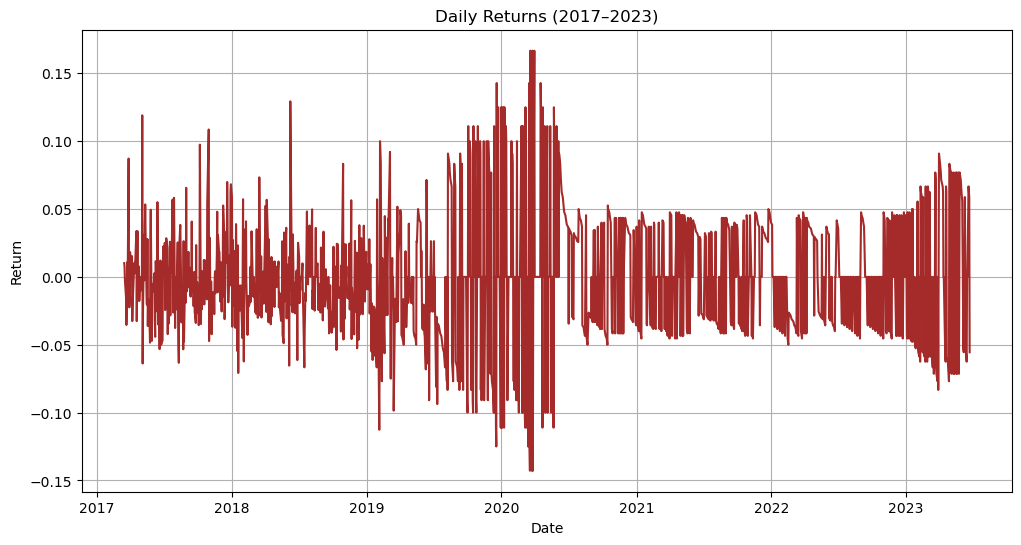

In [21]:
# Line chart (Daily Returns Trend)
plt.figure(figsize=(12,6))
plt.plot(data['Daily Return'], color='brown')
plt.title("Daily Returns (2017–2023)")
plt.xlabel("Date")
plt.ylabel("Return")
plt.grid()
plt.show()

In [23]:
# Daily returns are centered around zero, indicating no consistent positive or negative trend.
# Frequent small ups and downs indicate regular short-term activity.
# Some big spikes show sudden price changes.
# Volatility peaks around 2019–2020, showing a period of higher market uncertainty.
# In later years, fluctuations reduce and returns become more stable, suggesting lower volatility and reduced trading activity.

### Daily Volatility

In [25]:
daily_vol = data['Daily Return'].std()
print(f"Daily Volatility: {daily_vol*100:.2f}%")

Daily Volatility: 4.33%


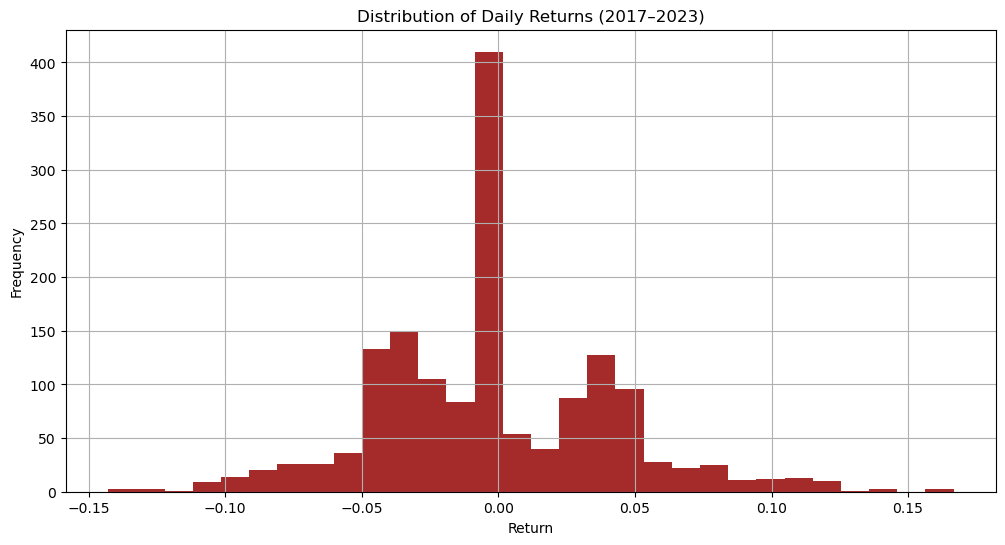

In [27]:
# Histogram (Distribution of Daily Returns)
plt.figure(figsize=(12,6))
plt.hist(data['Daily Return'].dropna(), bins=30, color='brown')
plt.title("Distribution of Daily Returns (2017–2023)")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.grid()
plt.show()

In [29]:
# Returns are widely spread, indicating high to very high volatility.
# Presence of extreme values on both sides highlights sudden and sharp price changes.
# The wide distribution suggests high risk and unpredictable market conditions.

### Annualized Volatility

In [31]:
annual_vol = daily_vol * np.sqrt(252)
print(f"Annualized Volatility: {annual_vol*100:.2f}%")

Annualized Volatility: 68.74%


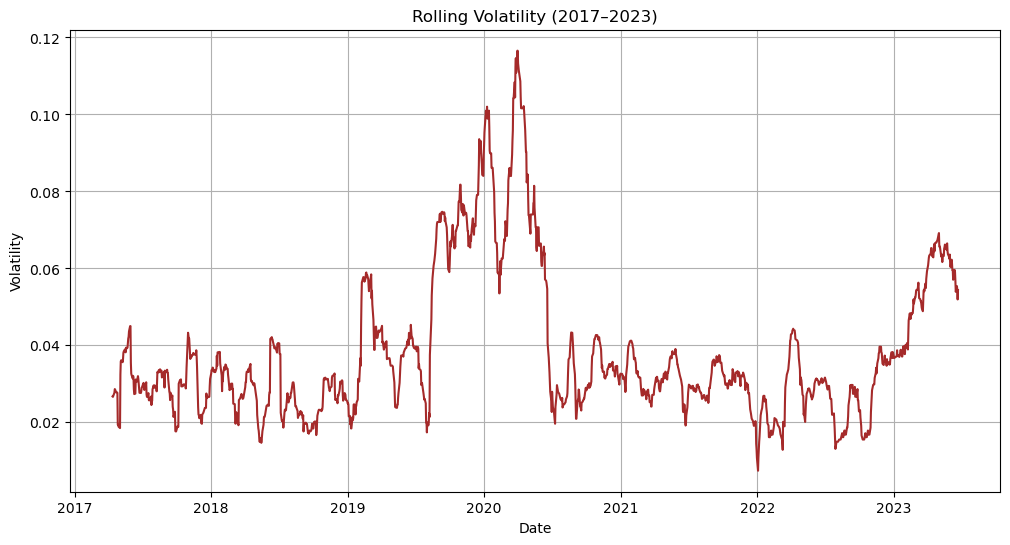

In [33]:
data['Rolling Volatility'] = data['Daily Return'].rolling(20).std()

# Line chart (Rolling Volatility Trend)
plt.figure(figsize=(12,6))
plt.plot(data['Rolling Volatility'], color='brown')
plt.title("Rolling Volatility (2017–2023)")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.grid()
plt.show()

In [35]:
# Volatility is moderate in the early years, indicating regular market fluctuations.
# A sharp increase around 2019–2020 shows periods of very high risk and instability.
# After this peak, volatility declines as the stock price drops significantly.
# A small rise is seen again around 2023, indicating brief instability.
# In recent years, volatility becomes nearly zero, reflecting no price movement and inactive trading.
# Overall, volatility decreases over time as the company becomes inactive.

### 📊 Conclusion

### Ballarpur Industries Limited stock shows a clear declining trend over time.
### - Volatility is higher in the initial years, indicating unstable and risky market conditions.
### - Prices decrease steadily with some sharp drops, reflecting continuous loss in value.
### - After the decline, the stock remains at very low levels with limited movement.
### - Daily returns are mostly small but include a few sudden spikes.
### - Overall, the stock moves from early instability to almost no activity, indicating a near-shutdown condition.